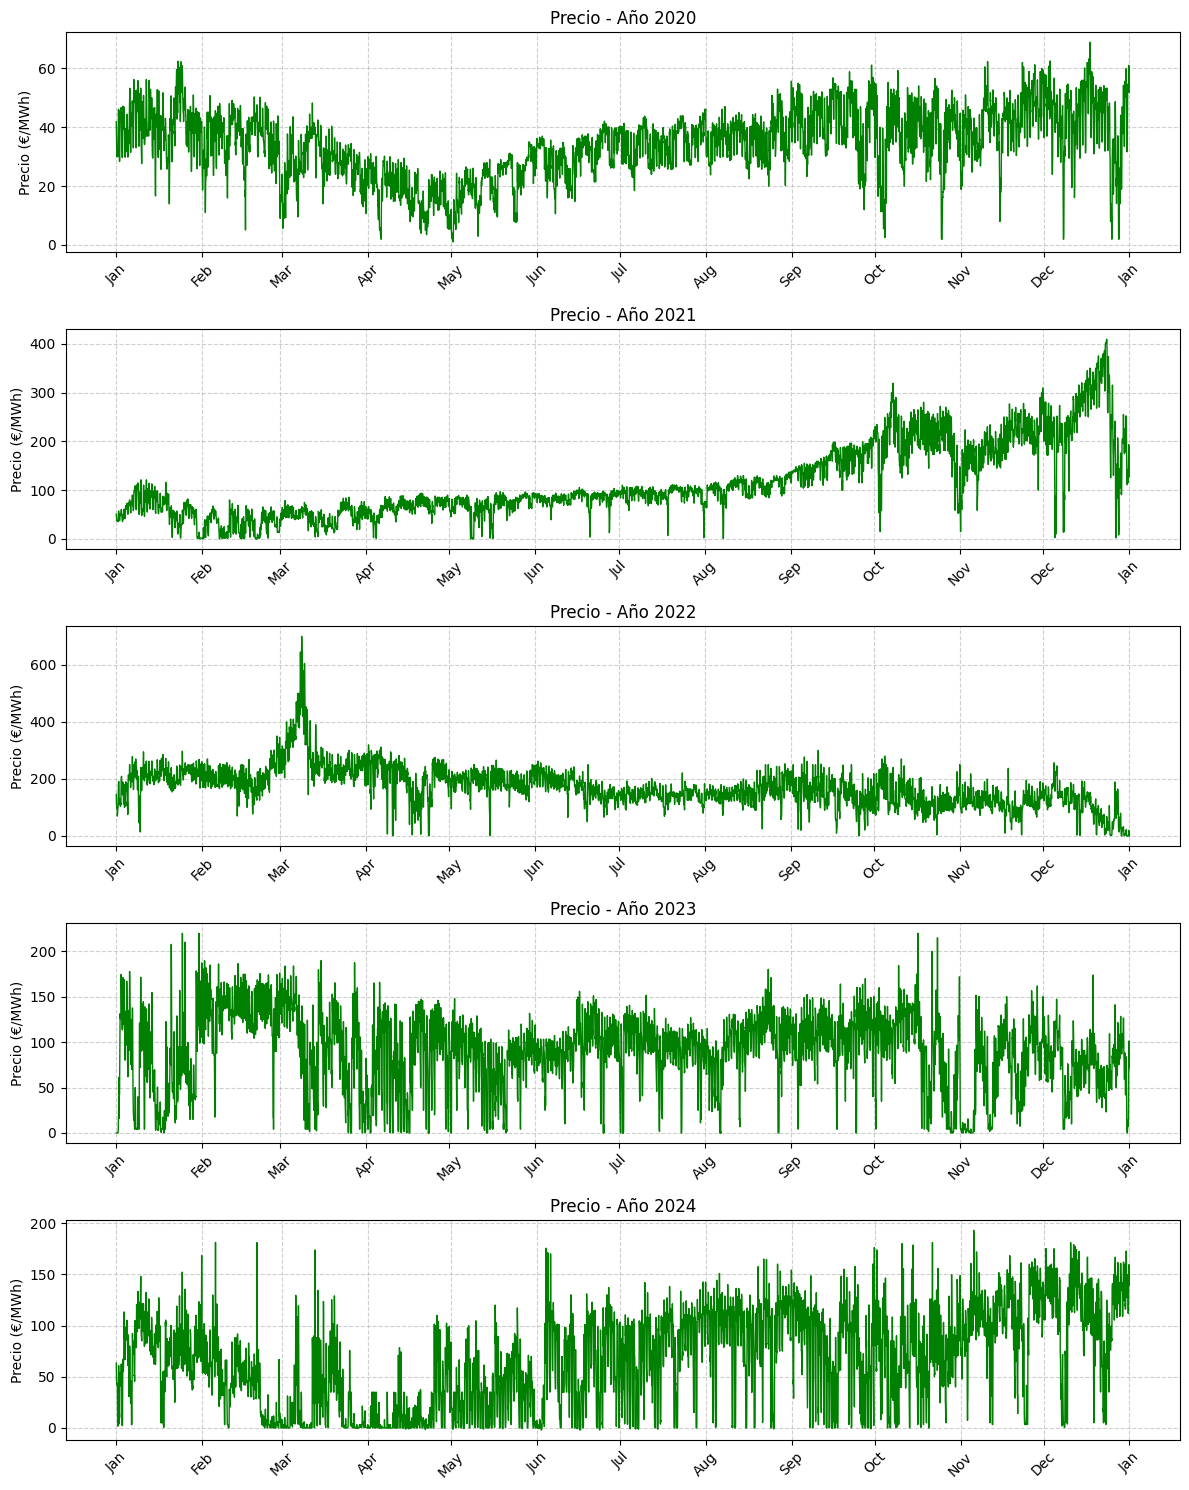

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.dates import MonthLocator, DateFormatter


# ==============================
# 1. Cargar y preparar la serie 
# ==============================
df_precio = pd.read_csv('limpiezaPrecio3_Omie2020_2024.csv', sep=";")
df_precio['datetime'] = pd.to_datetime(df_precio['datetime'])
#ordenar por fecha por si acaso
df_precio.set_index('datetime', inplace=True)
df_precio.sort_index(inplace=True) 

df = df_precio.copy()  
# ==============================
# 2. Grafica de precio por año (subplots)
# ==============================


# Extraer el año de cada fecha
df['year'] = df.index.year

# Obtener años únicos ordenados
years = sorted(df['year'].unique())

# Crear una figura con tantos subplots como años
fig, axes = plt.subplots(nrows=len(years), ncols=1, 
                         figsize=(12, 3*len(years)), 
                         sharex=False, sharey=False)

# Para cada año, graficar la serie de precios
for ax, year in zip(axes, years):
    data_year = df[df['year'] == year]
    ax.plot(data_year.index, data_year['price'], 
            color='green', linewidth=1)
    ax.set_title(f'Precio - Año {year}', fontsize=12)
    ax.set_ylabel('Precio (€/MWh)')
    #ax.legend(['Precio (€/MWh)'], loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)
    # Formato del eje X para mostrar meses
    #ax.xaxis.set_major_locator(MonthLocator(bymonth=(1,4,7,10)))  # cada 3 meses
    ax.xaxis.set_major_locator(MonthLocator(bymonth=())) 
    ax.xaxis.set_major_formatter(DateFormatter('%b'))  # Ene, Feb... en lugar de 2020-01...

    # Opcional: rotar etiquetas por si se solapan los años
    ax.tick_params(axis='x', rotation=45)

# Ajustar espacio entre subplots y mostrar
plt.tight_layout()
plt.show()





## Cualidades de las Series temporales

### 1. Trend/Tendencia

La forma que toma la pendiente de la serie o la dirección general a largo plazo (subida, bajada, estable)

### 2. Seasonality/Estacionalidad

Son los patrones que se repiten en intervalos de tiempo regulares/fijos, por ejemplo el precio bajo los fines de semana

### 3. Ciclicality/Ciclico

Son los patrones que se repiten, pero sin un intervalo de tiempo regular. Por ejemplo, cuando baja y luego vuelve a subir al precio en el que se encontraba varias veces a lo largo del año

### 4. Stationary/Estacionariedad

Significa que la distribucion de la serie no cambia con el tiempo. Para que una serie sea estacionaria:

* Tendencia no sea significativa (ni crece ni decrece mucho )

* La varianza es constante (la media de la distancia entre los valores y 0 no cambia)

* La autocorrelacion es constante (los valores son dependientes de los vecinos, esto no cambia)

### 4. Ruido Blanco o residuo 
Son valores que no tienen relacion con los anteriores. Por ejemplo al tirar una moneda al aire, el resultado no
depende del anterior. Lo ideal deberia ser ruido aleatorio sin ningun patron. Son lo que NO pudo explicar ni la tendencia ni la estacionalidad

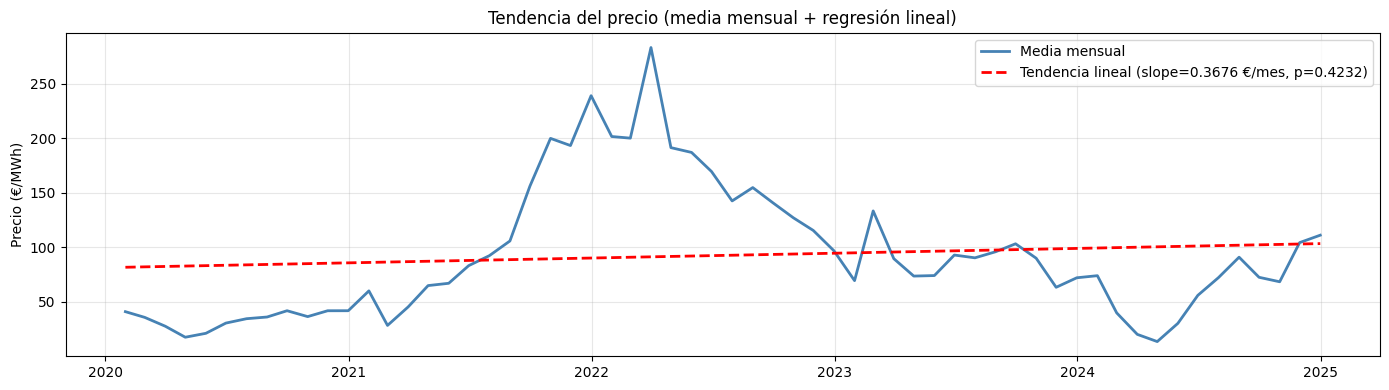


TENDENCIA
  Pendiente: el precio cambia en 0.3676 €/MWh por mes
  Dirección: creciente
  R: 0.1053 correlacion minima, mide la fuerza de la correlación lineal (-1 y 1)
  R²: 0.0111, 1 es correlación perfecta - 0 es nula
  p-valor: 0.4232, tendencia no significativa
  se : 0.4558, error estándar entre la pendiente y el valor real 
  La Tendencia NO es significativa


In [ ]:


# ==============================
# 1. Tendencia
# ==============================
from scipy.stats import linregress

#serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna()
#serie = serie.asfreq('m')

fig, ax = plt.subplots(figsize=(14, 4))

# 1.1 Media mensual suavizada
monthly = df['price'].resample('ME').mean() 
ax.plot(monthly.index, monthly.values, color='steelblue', lw=2, label='Media mensual')

# 1.2 Calcular recta de regresión sobre la media mensual
x_num = np.arange(len(monthly)) # array numérico desde 0 hasta n-1 meses
slope, intercept, r, p, se = linregress(x_num, monthly.values)
trend_line = intercept + slope * x_num #y = mx + b: Calcular los valores de la linea recta de regresion para cada punto
ax.plot(monthly.index, trend_line, '--', color='red', lw=2,
        label=f'Tendencia lineal (slope={slope:.4f} €/mes, p={p:.4f})')

ax.set_title('Tendencia del precio (media mensual + regresión lineal)')
ax.set_ylabel('Precio (€/MWh)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTENDENCIA")
print(f"  Pendiente: el precio cambia en {slope:.4f} €/MWh por mes")

direction = "nula"
if(slope > 0):
    direction = "creciente"
elif(slope < 0):
    direction = "decreciente"
#direction = "creciente" if slope > 0 else "decreciente" if slope < 0 else "nula"

correlacion = "minima"
if r > 0.5:
    correlacion = "positiva"
elif r < -0.5:
    correlacion = "negativa"

"negativa" if r < 0.5 else "nula"

tendencia = "no significativa"
if (p < 0.05):
    tendencia = "significativa"

print(f"  Dirección: {direction}")
print(f"  R: {r:.4f} correlacion {correlacion}, R mide la fuerza de la correlación lineal (-1 y 1)")
print(f"  R²: {r**2:.4f}, 1 es correlación perfecta - 0 es nula")
print(f"  p-valor: {p:.4f}, tendencia {'significativa' if p < 0.05 else 'no significativa'}")
print(f"  se : {se:.4f}, error estándar entre la pendiente y el valor real ")
print(f"  {'La Tendencia es estadísticamente significativa' if p < 0.05 else 'La Tendencia NO es significativa'}")

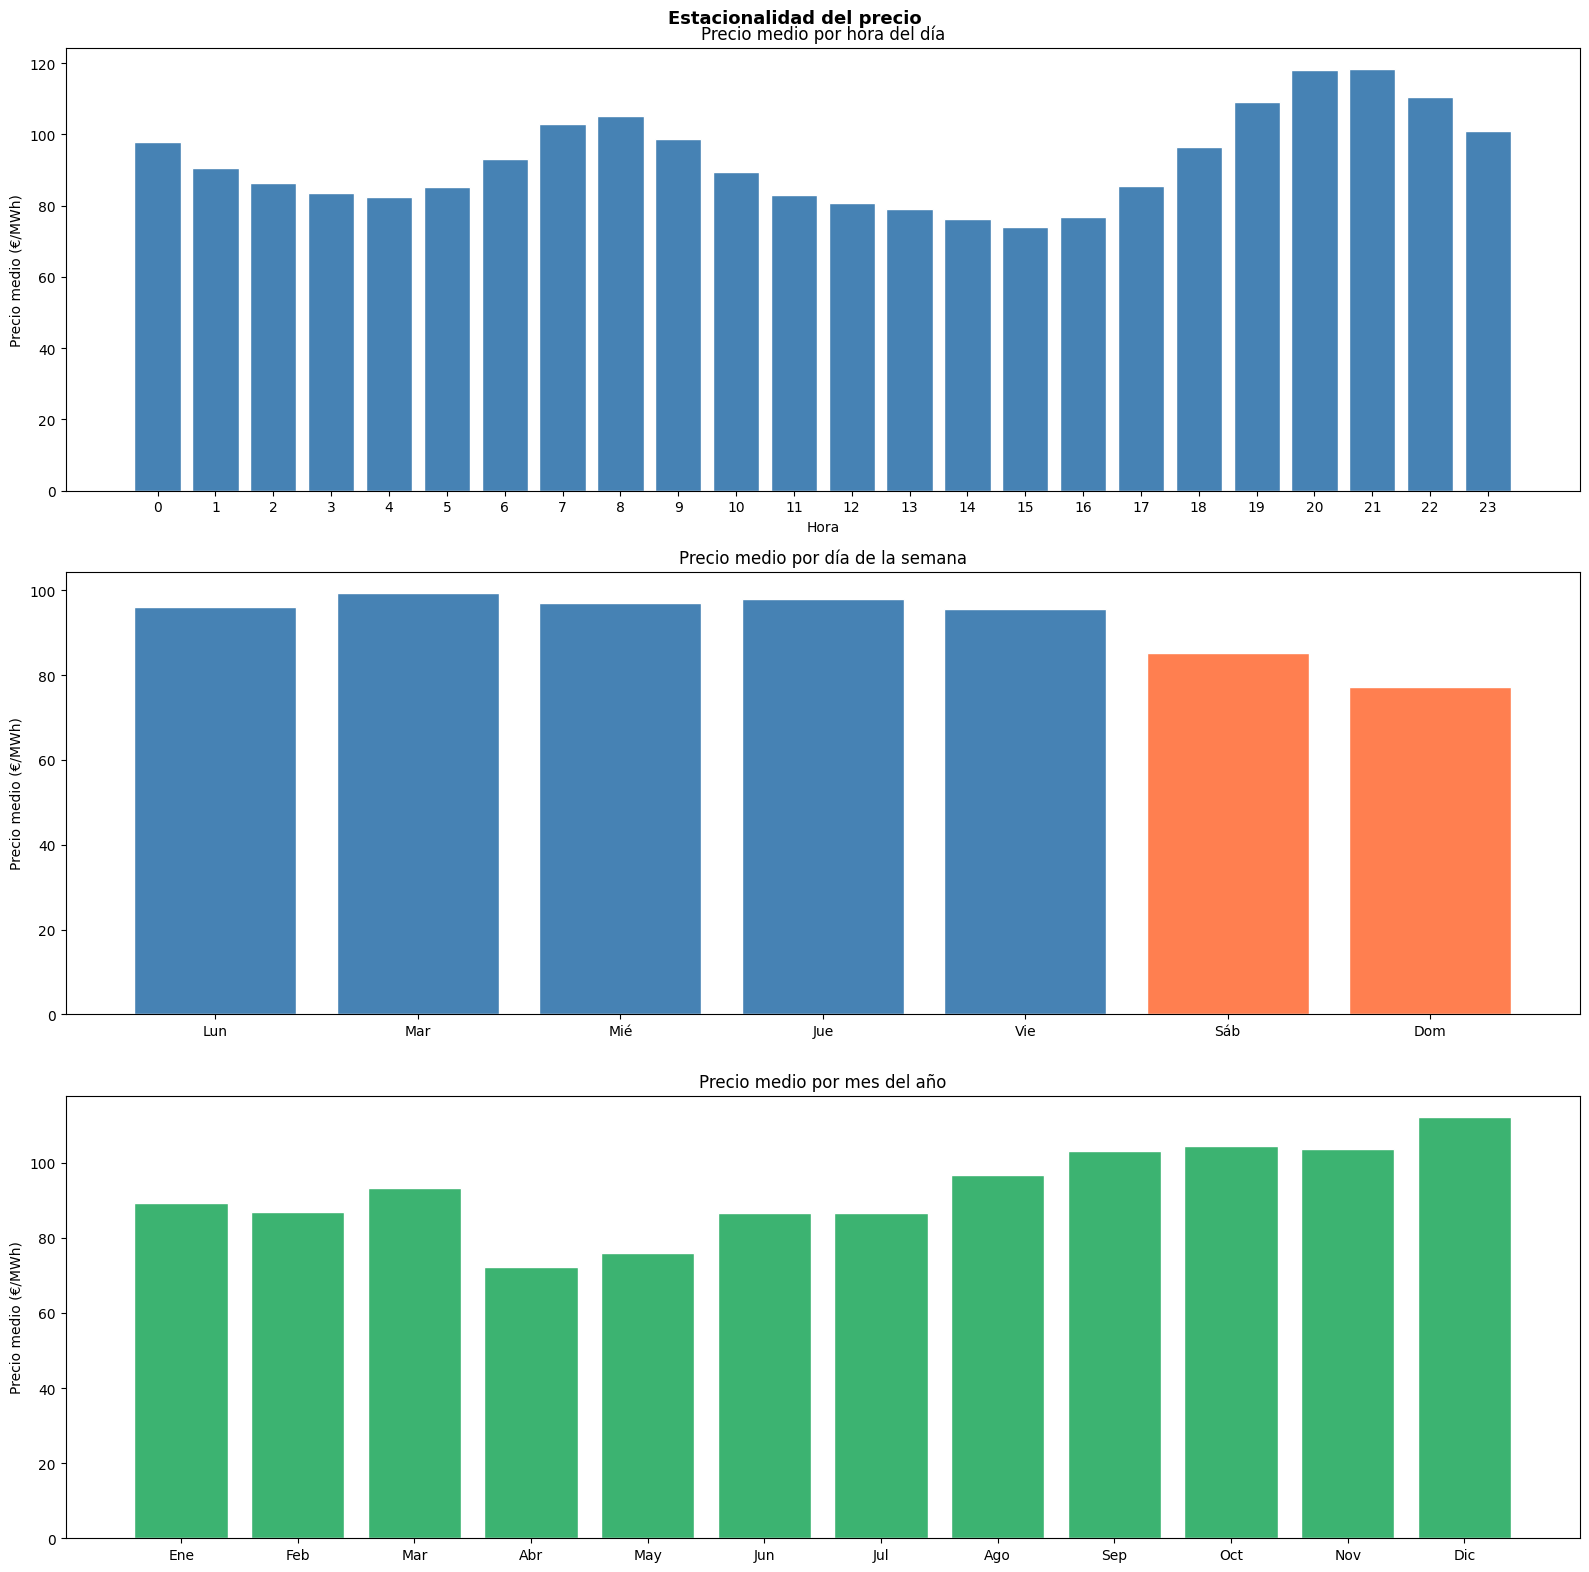


ESTACIONALIDAD
  Precio máximo por hora: hora 21 (118.38 €/MWh)
  Precio mínimo por hora: hora 15 (74.05 €/MWh)
  Precio medio dias laborables: 97.23 €/MWh
  Precio medio fines de semana: 81.24 €/MWh
  Mes más caro:  Dic (112.30 €/MWh)
  Mes más barato: Abr (72.32 €/MWh)


In [4]:

# ==============================
# 2. Estacionalidad
# ==============================

#fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# 2.2 Precio medio por hora del día
hourly_mean = df.groupby('hour')['price'].mean()
axes[0].bar(hourly_mean.index, hourly_mean.values, color='steelblue', edgecolor='white')
axes[0].set_title('Precio medio por hora del día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Precio medio (€/MWh)')
axes[0].set_xticks(range(0, 24, 1))

# 2.3 Precio medio por día de la semana
df['weekday'] = df.index.weekday
weekday_mean = df.groupby('weekday')['price'].mean()
days = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
colors = ['steelblue']*5 + ['coral']*2 # primeras 5 barras azules para dias laborables, últimas 2 coral para fines de semana
axes[1].bar(days, weekday_mean.values, color=colors, edgecolor='white')
axes[1].set_title('Precio medio por día de la semana')
axes[1].set_ylabel('Precio medio (€/MWh)')

# 2.4 Precio medio por mes
df['month'] = df.index.month
monthly_mean = df.groupby('month')['price'].mean()
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
axes[2].bar(month_names, monthly_mean.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Precio medio por mes del año')
axes[2].set_ylabel('Precio medio (€/MWh)')

plt.suptitle('Estacionalidad del precio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticos de estacionalidad
print(f"\nESTACIONALIDAD")
print(f"  Precio máximo por hora: hora {hourly_mean.idxmax()} ({hourly_mean.max():.2f} €/MWh)")
print(f"  Precio mínimo por hora: hora {hourly_mean.idxmin()} ({hourly_mean.min():.2f} €/MWh)")
print(f"  Precio medio dias laborables: {weekday_mean[:5].mean():.2f} €/MWh")
print(f"  Precio medio fines de semana: {weekday_mean[5:].mean():.2f} €/MWh")
print(f"  Mes más caro:  {month_names[monthly_mean.idxmax()-1]} ({monthly_mean.max():.2f} €/MWh)")
print(f"  Mes más barato: {month_names[monthly_mean.idxmin()-1]} ({monthly_mean.min():.2f} €/MWh)")

## Seasonal-Trend decomposition using LOESS
La descomposición STL es una técnica estadística que separa una serie temporal en tres componentes fundamentales para entender mejor su comportamiento. 
* Serie Original = Tendencia + Estacionalidad + Residuo (Ruido)

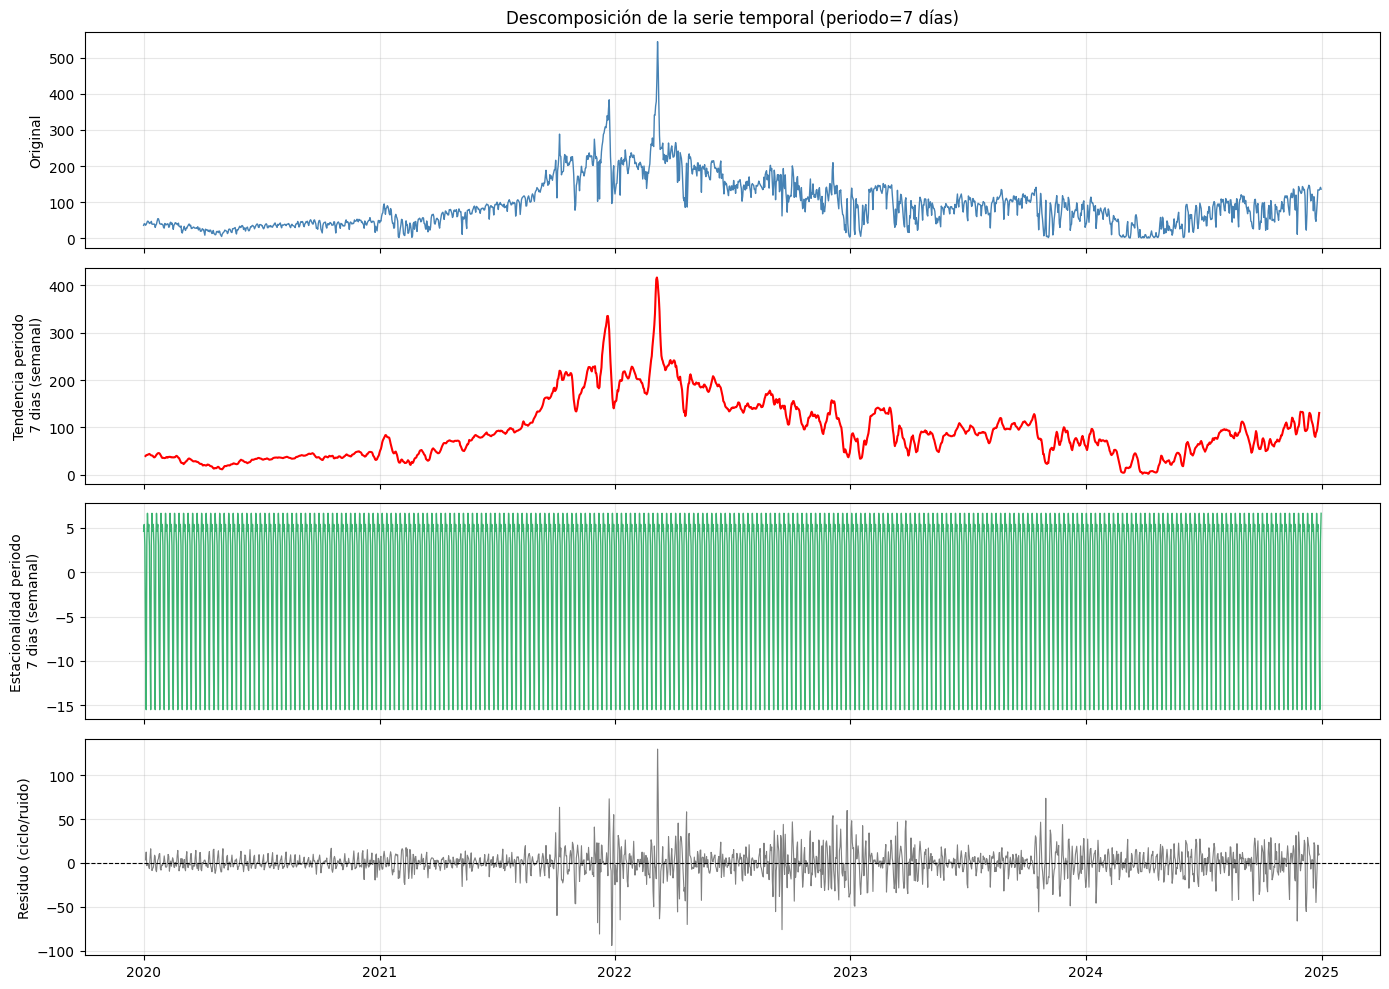


DESCOMPOSICIÓN STL
Varianza total:         4423.93
Varianza por componente:
  % explicado tendencia: un 90.9% se debe a la tendencia a largo plazo
  % explicado estacional: un 1.3% se debe a patrones estacionales (ciclo semanal)
  % residuo (ciclo+ruido): un 5.5% es aleatorio o por causas puntuales

La tendencia domina, el precio esta subiendo estructuralmente a largo plazo
Días anómalos: 95


In [ ]:

# ==============================
# 3. DESCOMPOSICIÓN STL
# ==============================

from statsmodels.tsa.seasonal import seasonal_decompose

# Serie diaria (media por día) para análisis de tendencia/estacionalidad
daily = df['price'].resample('D').mean()

# Usamos serie diaria con periodo 7 (semana) para ver ciclos semanales
# model='additive'-> Original = Tendencia + Estacionalidad + Residuo
decomposition = seasonal_decompose(daily.dropna(), model='additive', period=7)


#Visualizar la descomposición
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily.index, daily.values, color='steelblue', lw=1)
axes[0].set_ylabel('Original')
axes[0].set_title('Descomposición de la serie temporal (periodo=7 días)')

axes[1].plot(decomposition.trend.index, decomposition.trend.values, color='red', lw=1.5)
axes[1].set_ylabel('Tendencia periodo\n 7 dias (semanal)')

axes[2].plot(decomposition.seasonal.index, decomposition.seasonal.values, color='mediumseagreen', lw=1)
axes[2].set_ylabel('Estacionalidad periodo\n 7 dias (semanal)')

axes[3].plot(decomposition.resid.index, decomposition.resid.values, color='gray', lw=0.8)
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_ylabel('Residuo (ciclo/ruido)')

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Varianza total y de cada componente
total_var = np.var(daily.dropna())
trend_var = np.var(decomposition.trend.dropna())
seas_var  = np.var(decomposition.seasonal.dropna())
resid_var = np.var(decomposition.resid.dropna())

print(f"\nDESCOMPOSICIÓN STL")
print(f"Varianza total:         {total_var:.2f}")
print(f"Varianza por componente:")
print(f"  % explicado tendencia: un {100*trend_var/total_var:.1f}% se debe a la tendencia a largo plazo")
print(f"  % explicado estacional: un {100*seas_var/total_var:.1f}% se debe a patrones estacionales (ciclo semanal)")
print(f"  % residuo (ciclo+ruido): un {100*resid_var/total_var:.1f}% es aleatorio o por causas puntuales\n")

# Los precios estan subiendo estructuralmente o solo por estacionalidad?
if trend_var > seas_var:
    print("La tendencia domina, el precio esta subiendo estructuralmente a largo plazo")
else:
    print("La estacionalidad domina, principalmente patrones semanales")

# Residuo: dias con precio muy alto o bajo respecto a lo esperado por tendencia+estacionalidad
# Días con residuo > 2 desviaciones estandar, posibles eventos atipicos o cambios estructurales
anomalies = decomposition.resid[abs(decomposition.resid) > 2 * decomposition.resid.std()]
print(f"Días anómalos: {len(anomalies)}")

In [ ]:
# ==============================
# 4. Ruido Blanco
# ==============================

from statsmodels.stats.diagnostic import acorr_ljungbox

residuos = decomposition.resid.dropna()
# test de ruido blanco:
# ljungbox examina si los residuos tienen correlación con sus propios valores pasados o si son aleatorios
# Ho (hipótesis nula): Los residuos son ruido blanco (no hay autocorrelación)
# H1 (hipótesis alternativa): Existe autocorrelación (hay patrón)
# lags=10 analiza los primeros 10 retardos (hasta 10 periodos atras)
resultado = acorr_ljungbox(residuos, lags=10)

'''# Extraemos el p-valor para el primer retardo (lag=1)
first_p = resultado['lb_pvalue'].iloc[0]
print(f"Ljung-Box p-value (lag=1): {first_p:.4f}")

if first_p > 0.05:
    print("Los residuos son aleatorios, bueno")
else:
    print("Los residuos tienen patron, no es recomendable porque puede quedar informacion util en los residuos")'''

# Test para lags de 7, 14 y 30 días (1 semana, 2 semanas y 1 mes)
lb_test = acorr_ljungbox(daily.dropna(), lags=[7, 14, 30], return_df=True)
print(f"\nTEST LJUNG-BOX")
print(lb_test.to_string())
if (lb_test['lb_pvalue'] > 0.05).all():
    print("la serie se comporta como ruido blanco")
else:
    print("la serie NO es ruido blanco (tiene estructura/autocorrelacion)")


TEST LJUNG-BOX
         lb_stat  lb_pvalue
7    9740.042457        0.0
14  17932.722867        0.0
30  35172.196894        0.0
la serie NO es ruido blanco (tiene estructura/autocorrelación)


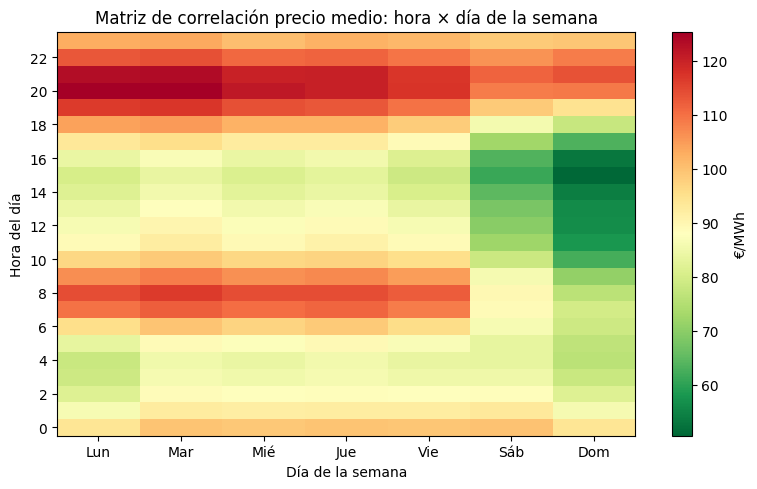

In [ ]:
# ==============================
# 5. Matriz de correlación 
# ==============================

# Heatmap de autocorrelación hora × día de la semana
pivot = df.pivot_table(values='price', index='hour', columns='weekday', aggfunc='mean')
pivot.columns = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', origin='lower')
ax.set_xticks(range(7)); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(0, 24, 2)); ax.set_yticklabels(range(0, 24, 2))
ax.set_xlabel('Día de la semana'); ax.set_ylabel('Hora del día')
ax.set_title('Matriz de correlación precio medio: hora × día de la semana')
plt.colorbar(im, ax=ax, label='€/MWh')
plt.tight_layout()
plt.show()